In [11]:
# all necessary libraries imported
# Work done by Kazi Abrar Hossain in collaboration with Su Zijin

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [12]:
# Define basic parameters
freq = 10.425e9  # Frequency (10 GHz)
c = 3e8   # Speed of light (m/s)
lambda_ = c / freq  # Calculate wavelength
k_0 = 2 * np.pi / lambda_  # Wavenumber
cell_size = 0.015
D_x = 0.6  # Array size in X direction (m)
D_y = 0.3  # Array size in Y direction (m)
nx = int(D_x/cell_size)
ny = int(D_y/cell_size)
dx = D_x / nx  # Element spacing in X direction
dy = D_y / ny  # Element spacing in Y direction
ndim = 2

# far field distance calculation

fz = (2 * (D_x)**2)/lambda_

print(ny)
eta = 1.16666667 #efficiency parameter for focal length of transmitter
focal = D_x * eta

print(focal)

20
0.7000000019999999


In [13]:
def generate_grid(x_range, y_range):
    """
    Generates a grid of x, y coordinates within the specified ranges.

    Args:
        x_range:(x_min, x_max) defining the range for the x-coordinates.
        y_range:(y_min, y_max) defining the range for the y-coordinates.

    Returns:
        A NumPy array of shape (n, 2) where each row represents a coordinate (x, y)
        on the grid.

    """
    x_min, x_max = x_range
    y_min, y_max = y_range

    x = np.linspace(x_min, x_max, nx)
    y = np.linspace(y_min, y_max, ny)


    # Create the meshgrid
    xx, yy = np.meshgrid(x, y)

    # Reshape to get in position vector form (n, 2) array
    coordinates = np.column_stack((xx.flatten(), yy.flatten()))
    return coordinates

# Defining the grid for the reflectarray dimension chosen
x_range = (-0.3, 0.3)
y_range = (-0.15, 0.15)
z_range = (0, 0)

grid_coord = generate_grid(x_range, y_range)


def distance_to_3d_points(point, coordinates):
    """
    Calculates the Euclidean distance from a point to every 3D coordinate.

    Args:
        point: A list representingo the coordinates of the point (x, y, z).
        coordinates: A NumPy array of shape (n, 3) where each row represents a
                     3D coordinate (x, y, z).

    Returns:
        A NumPy array of shape (n,2) containing the distances.
    """
    point = np.array(point)

    distances = np.linalg.norm(coordinates - point, axis=1)
    return distances



# Create 3D coordinates from the 2D grid:
grid_3d_coordinates = np.column_stack((grid_coord, np.full(grid_coord.shape[0], 0)))

feed_posi = np.array([0, 0, focal])

# Calculating distance from feed to every element on the array
d_i = distance_to_3d_points(feed_posi, grid_3d_coordinates)

# Calculating distance to center of array
d_0 = np.sqrt(grid_coord[:,0]**2 + grid_coord[:,1]**2)


# target collimate beam spherical direction
theta_0 = np.radians(0)  # elevation angle
phi_0 = np.radians(0)  # azimuth angle

np.info(grid_3d_coordinates)


class:  ndarray
shape:  (800, 3)
strides:  (24, 8)
itemsize:  8
aligned:  True
contiguous:  True
fortran:  False
data pointer: 0x3959ee0
byteorder:  little
byteswap:  False
type: float64


class:  ndarray
shape:  (800,)
strides:  (8,)
itemsize:  8
aligned:  True
contiguous:  True
fortran:  True
data pointer: 0x3996c50
byteorder:  little
byteswap:  False
type: float64
218.34068942449062


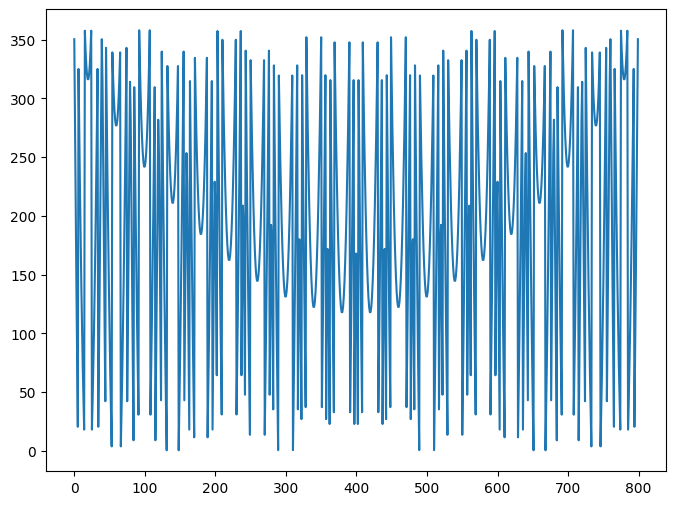

In [14]:
def calculate_phase_shifts(k0, di, d0, theta0, grid_coord, phi0):
    """Calculates phase shifts for an array of points.

    Args:
        k0: Wavenumber.     [m]
        di: Array of distances from feed antenna to points
        d0: Distance from ith unitcell to the origin(taken as the reference)
        theta0: Elevation angle
        grid_coord: NumPy array of shape (n, 2) with x, y coordinates
        phi0: Azimuth angle

    Returns:
        NumPy array of phase shifts
    """
    #v1.0 phase_shifts = np.mod(k0 * (di - d0 - (np.sin(theta0) * grid_coord[:, 0] * np.cos(phi0) + grid_coord[:, 1] * np.sin(phi0))), 2*np.pi)
    #c1.2 phase_shifts = np.mod(k0 * (d_i - np.sin(theta0) * (np.cos(phi0) * grid_coord[:, 0] + np.sin(phi0) * grid_coord[:, 1])), 2*np.pi)
    alpha = np.arctan2(grid_coord[:, 1], grid_coord[:, 0])

    phase_shifts = np.mod(k0 * (di - d0*np.sin(theta0) * (np.cos(phi0-alpha))), 2*np.pi)
    return phase_shifts

pha_i = calculate_phase_shifts(k_0, d_i, d_0, theta_0, grid_coord, phi_0)

np.info(pha_i)
print(k_0)

plt.figure(figsize=(8, 6))  # Adjust figure size as needed
plt.plot(np.rad2deg(pha_i)) # cmap options: viridis, magma, inferno, cividis, spring, summer, autumn, winter, coolwarm, bwr, rainbow
plt.show()

# 新段落

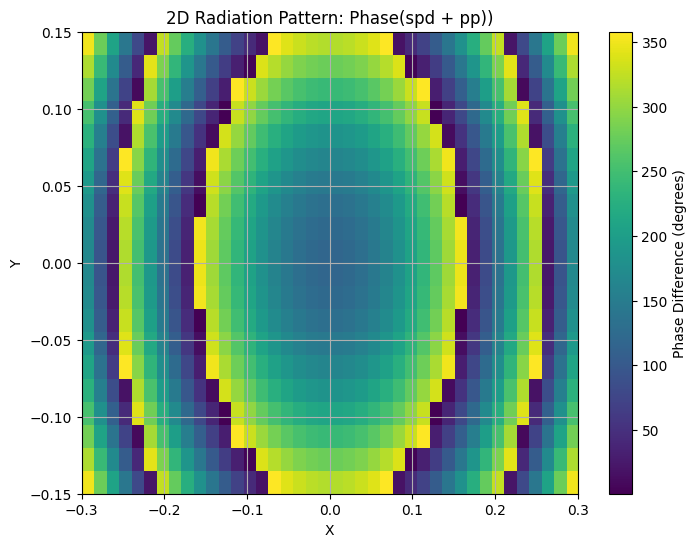

In [15]:
x = np.linspace(-0.3, 0.3, nx)
y = np.linspace(-0.15, 0.15, ny)
xx, yy = np.meshgrid(x, y)
xxc = pha_i.reshape(yy.shape)  # Reshape to match grid dimensions

# Create the 2D color plot:
plt.figure(figsize=(8, 6))  # Adjust figure size as needed
plt.imshow(np.rad2deg(xxc), extent=[x_range[0], x_range[1], y_range[0], y_range[1]], origin='lower', aspect='auto', cmap='viridis') # cmap options: viridis, magma, inferno, cividis, spring, summer, autumn, winter, coolwarm, bwr, rainbow
plt.colorbar(label='Phase Difference (degrees)')  # Add a colorbar
plt.xlabel('X')
plt.ylabel('Y')
plt.title('2D Radiation Pattern: Phase(spd + pp))')
plt.grid(True) # Add a grid
plt.show()

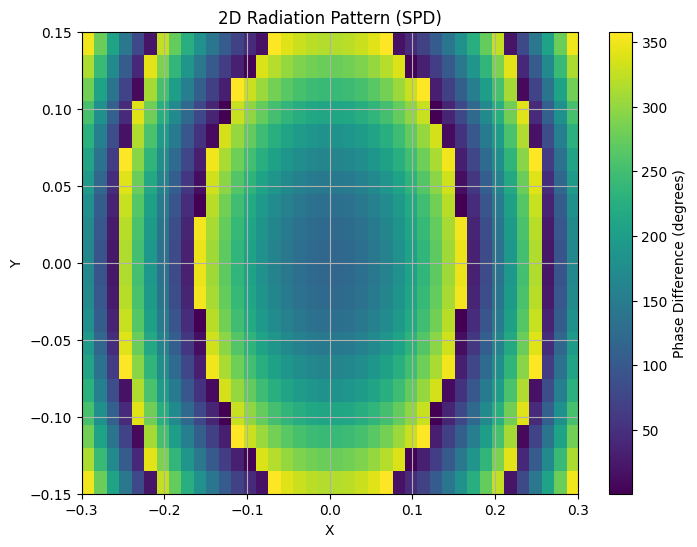

In [16]:
# same colour plot distribution but only for the spd
spd_pha = np.mod(k_0 * (d_i), 2*np.pi)
spd_pha_reshaped = spd_pha.reshape(yy.shape)  # Reshape to match grid dimensions

# Create the 2D color plot:
plt.figure(figsize=(8, 6))  # Adjust figure size as needed
plt.imshow(np.rad2deg(spd_pha_reshaped), extent=[x_range[0], x_range[1], y_range[0], y_range[1]], origin='lower', aspect='auto', cmap='viridis') # cmap options: viridis, magma, inferno, cividis, spring, summer, autumn, winter, coolwarm, bwr, rainbow
plt.colorbar(label='Phase Difference (degrees)')  # Add a colorbar
plt.xlabel('X')
plt.ylabel('Y')
plt.title('2D Radiation Pattern (SPD)')
plt.grid(True) # Add a grid
plt.show()

In [17]:
# Convert phase shift to degrees
pha_deg = np.rad2deg(xxc)
# Create a DataFrame to store (x, y, phase shift)
data = {
    "X (m)": xx.flatten(),
    "Y (m)": yy.flatten(),
    "Phase Shift (degrees)": pha_deg.flatten()
}

df = pd.DataFrame(data)
# Save phase shift data to a CSV file
df.to_csv("reflectarray_phase_shift.csv", index=False)


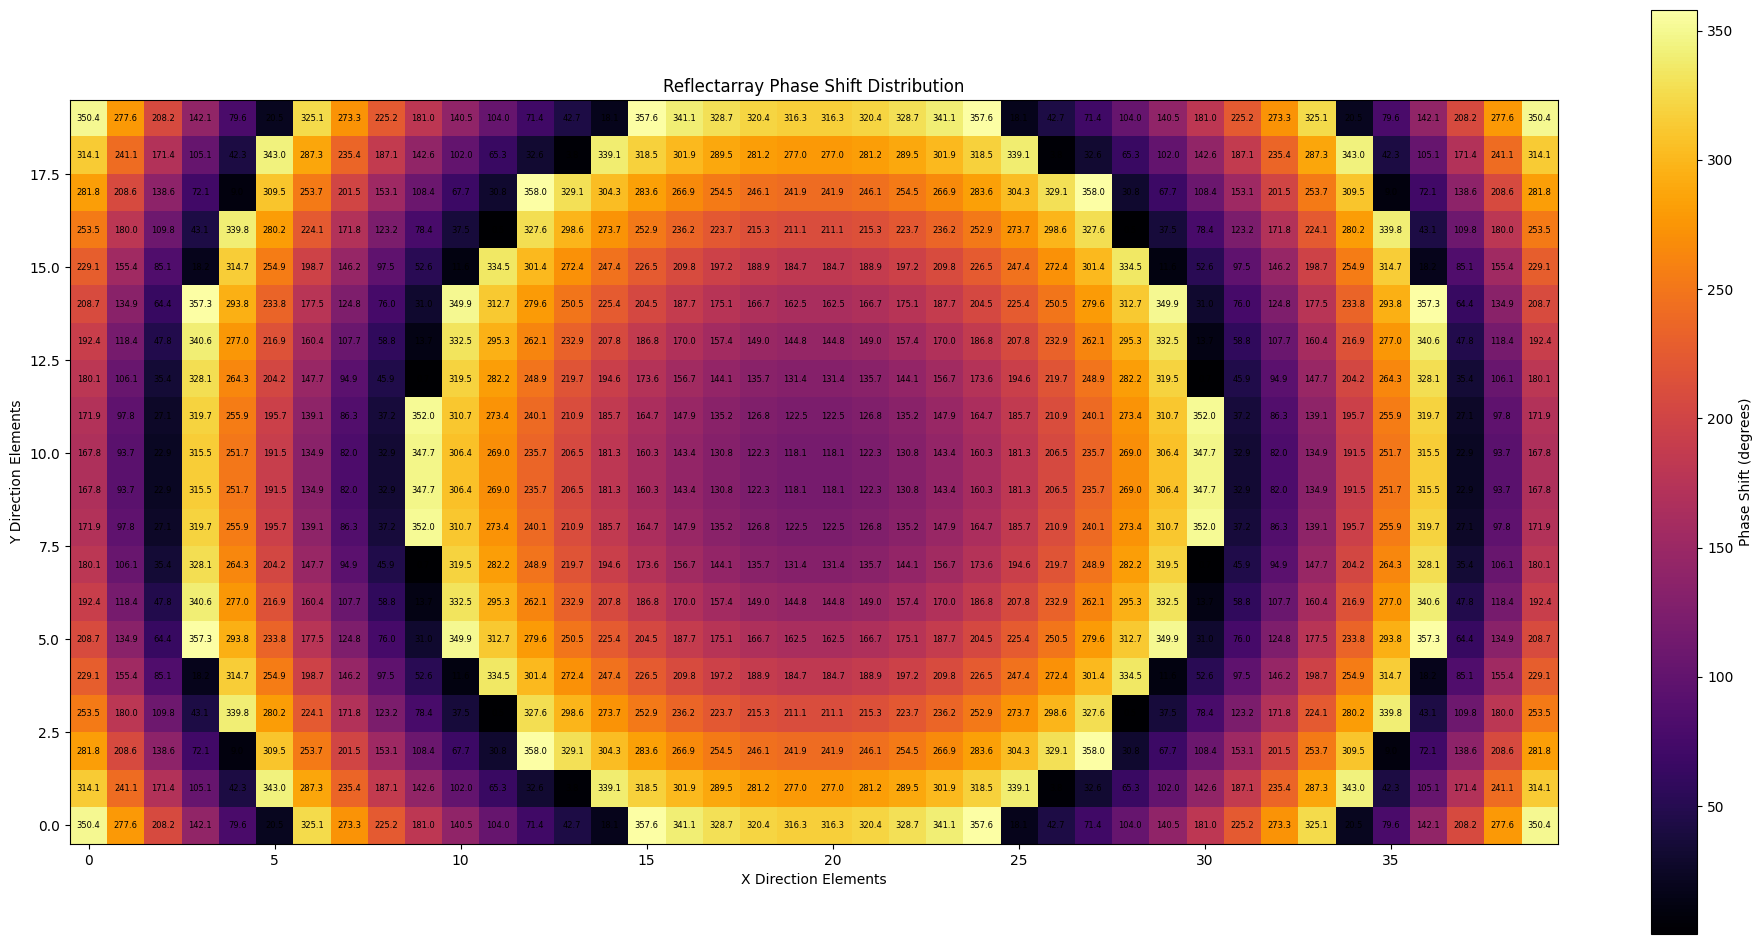

In [18]:
# Plot phase shift distribution with antenna annotation
fig, ax = plt.subplots(figsize=(24, 12))

# Display the phase distribution as an image
im = ax.imshow(np.rad2deg(xxc), cmap='inferno', origin='lower')
plt.colorbar(im, ax=ax, label='Phase Shift (degrees)')
ax.set_title('Reflectarray Phase Shift Distribution')
ax.set_xlabel('X Direction Elements')
ax.set_ylabel('Y Direction Elements')


# Add numerical labels to each grid cell (converted to degrees
# Add numerical labels to each grid cell (converted to degrees)
for i in range(ny):
    for j in range(nx):
        ax.text(j, i, f'{np.rad2deg(xxc[i, j]):.1f}', ha='center', va='center',
                color='black', fontsize=6)

plt.savefig("reflectarray_phase_shift_distribution.png", dpi=300, bbox_inches='tight')

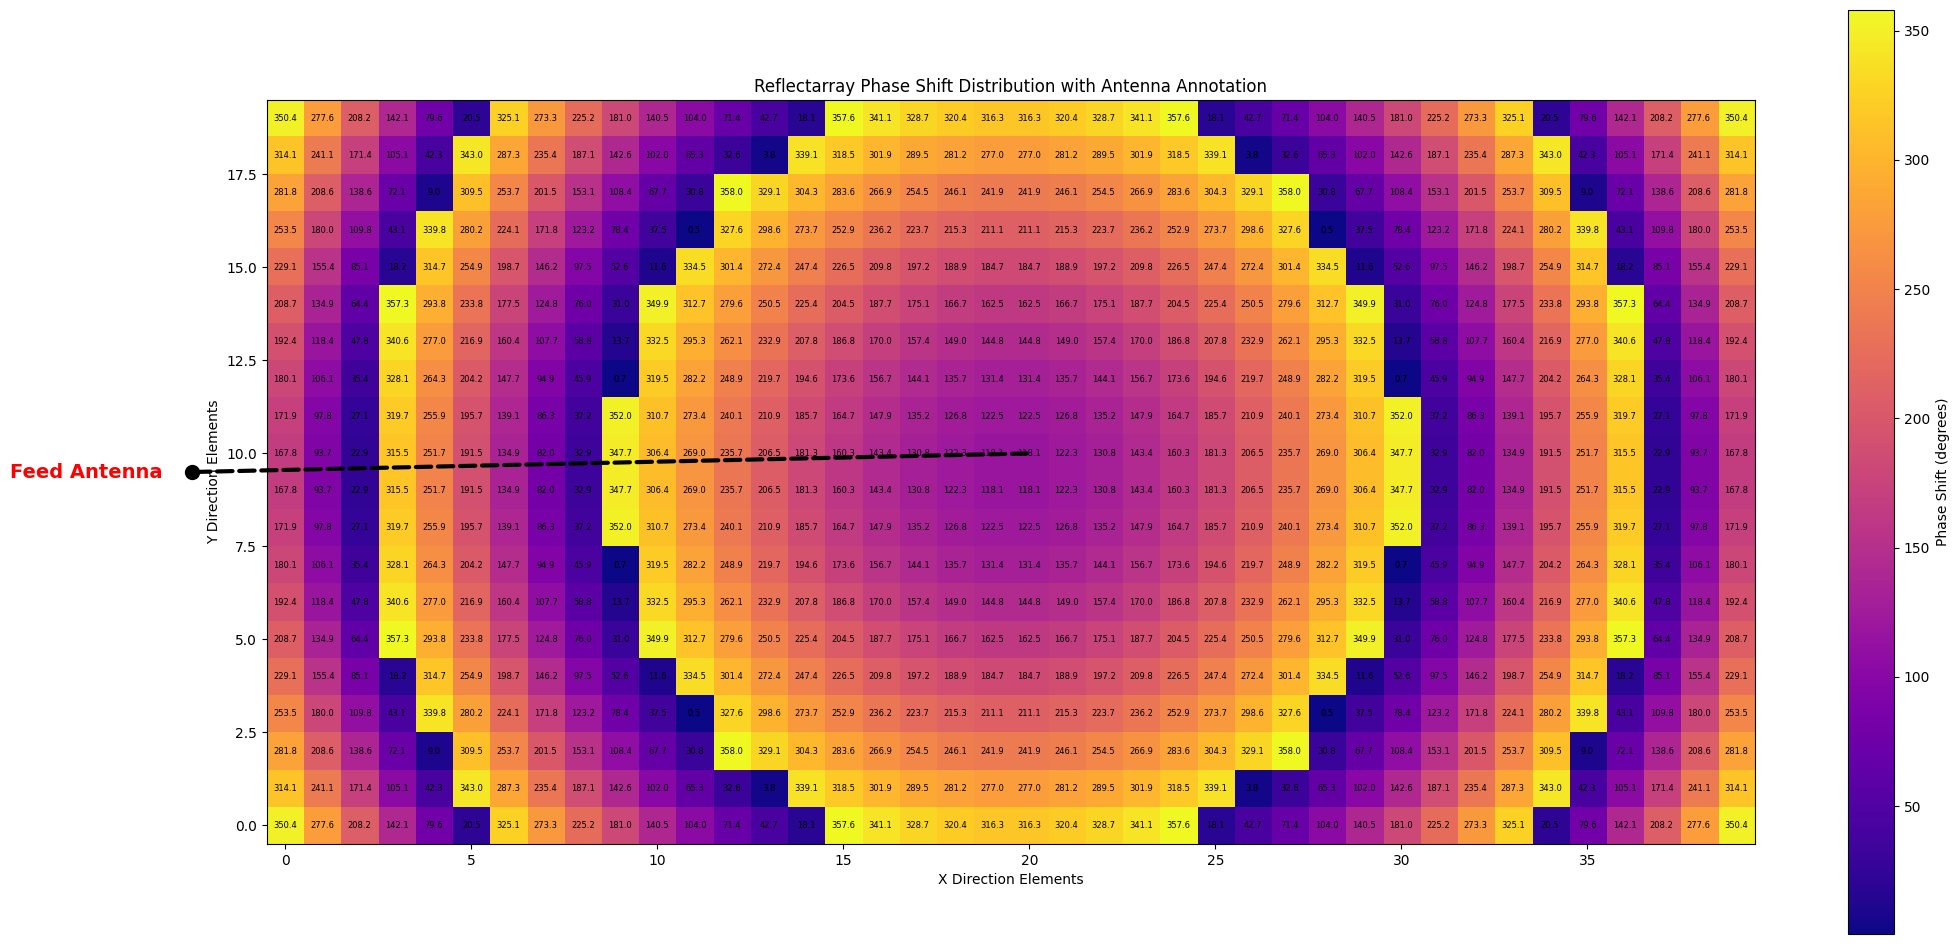

In [ ]:
# Plot phase shift distribution with antenna annotation
fig, ax = plt.subplots(figsize=(24, 12))

# Display the phase distribution as an image
im = ax.imshow(np.rad2deg(xxc), cmap='plasma', origin='lower')
plt.colorbar(im, ax=ax, label='Phase Shift (degrees)')
ax.set_title('Reflectarray Phase Shift Distribution with Antenna Annotation')
ax.set_xlabel('X Direction Elements')
ax.set_ylabel('Y Direction Elements')

# Add numerical labels to each grid cell (converted to degrees)
for i in range(ny):
    for j in range(nx):
        ax.text(j, i, f'{np.rad2deg(xxc[i, j]):.1f}', ha='center', va='center',
                color='black', fontsize=6)

# Define the feed position in data coordinates
feed_data_x = nx // 2
feed_data_y = ny // 2

# Define the external feed marker position in axes coordinates
external_feed_ax_x = -0.05  # Slightly left outside the axes
external_feed_ax_y = 0.5  # Vertically centered

# Draw the external feed marker as a visible circle
ax.plot(external_feed_ax_x, external_feed_ax_y, marker='o', markersize=10,
        markerfacecolor='black', markeredgecolor='black', linewidth=1,
        transform=ax.transAxes, clip_on=False, zorder=6)

# Add a label for the external feed marker
ax.text(external_feed_ax_x - 0.02, external_feed_ax_y, 'Feed Antenna', color='red',
        fontsize=14, fontweight='bold', ha='right', va='center',
        transform=ax.transAxes, clip_on=False)

# Draw a thick, dark dashed line connecting the feed position to the external marker
ax.annotate("",
            xy=(feed_data_x, feed_data_y),  # Feed position in data coordinates
            xycoords='data',
            xytext=(external_feed_ax_x, external_feed_ax_y),  # External marker in axes coordinates
            textcoords='axes fraction',
            arrowprops=dict(arrowstyle="-", linestyle='dashed',
                            color='black', linewidth=3, clip_on=False))

plt.show()

# 新段落

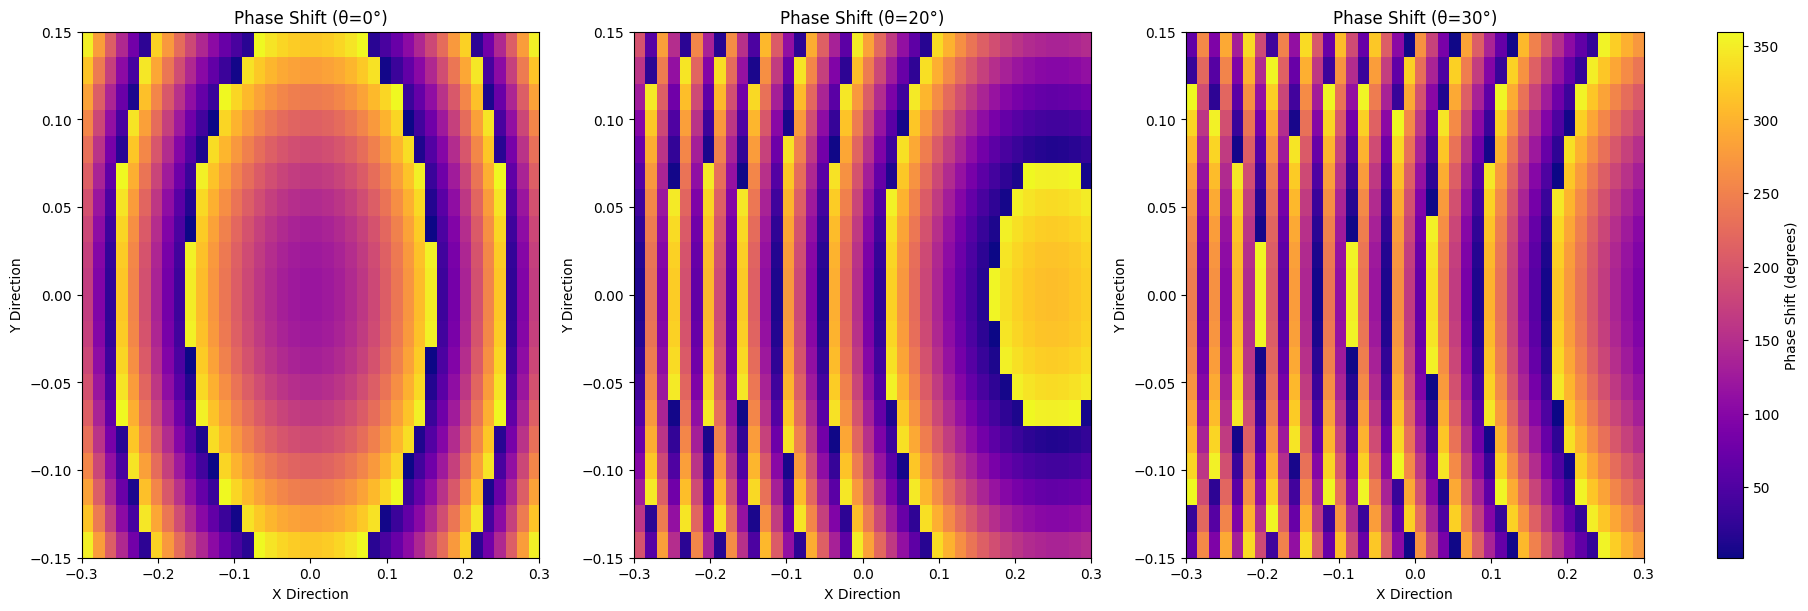

In [ ]:
# Create subplots for different theta angles with fixed setting
theta_test = [0, 20, 30]  # Different theta angles to test

num_thetas = len(theta_test)
fig, axes = plt.subplots(1, num_thetas, figsize=(6 * num_thetas, 6), constrained_layout=True)

if num_thetas == 1:
    axes = [axes]  # Ensure axes is iterable if there is only one subplot

im = None  # Store the last color plot for colorbar reference

for idx, theta in enumerate(theta_test):
    theta_0 = np.radians(theta)  # Convert theta angle to radians
    pha_i = calculate_phase_shifts(k_0, d_i, d_0, theta_0, grid_coord, phi_0)  # Compute phase shifts
    xxc = pha_i.reshape(yy.shape)  # Reshape into 2D grid format

    ax = axes[idx]
    im = ax.imshow(np.rad2deg(xxc), extent=[-D_x/2, D_x/2, -D_y/2, D_y/2],
                   origin='lower', aspect='auto', cmap='plasma')  # extent=[x_range[0], x_range[1], y_range[0], y_range[1]

    ax.set_title(f'Phase Shift (θ={theta}°)')
    ax.set_xlabel('X Direction')
    ax.set_ylabel('Y Direction')

# Add a single colorbar for the rightmost plot
fig.colorbar(im, ax=axes, orientation='vertical', fraction=0.02, pad=0.04, label='Phase Shift (degrees)')

plt.show()





In [ ]:
# Fast test with different value (theta,phi,feed pos)
def plot_phase_shift_distribution(theta_test, phi_test, feed_x, feed_y, feed_z):
    feed_pos = np.array([feed_x, feed_y, feed_z])
    d_i = distance_to_3d_points(feed_pos, grid_3d_coordinates)
    d_0 = np.sqrt(grid_coord[:, 0]**2 + grid_coord[:, 1]**2)
    theta_0 = np.radians(theta_test)
    phi_0 = np.radians(phi_test)

    pha_i = calculate_phase_shifts(k_0, d_i, d_0, theta_0, grid_coord, phi_0)
    xxc = pha_i.reshape(ny, nx)

    fig, ax = plt.subplots(figsize=(12, 6))
    im = ax.imshow(np.rad2deg(xxc), cmap='bwr', origin='lower',
                   extent=[-D_x/2, D_x/2, -D_y/2, D_y/2])
    plt.colorbar(im, ax=ax, label='Phase Shift (degrees)')
    ax.set_title(f'Phase Shift Distribution (Theta={theta_test}°, Phi={phi_test}°, Feed=({feed_x}, {feed_y}, {feed_z}))')
    ax.set_xlabel('X Position (m)')
    ax.set_ylabel('Y Position (m)')
    plt.show()

In [ ]:
from scipy.interpolate import interp1d

# steps to match data from HFSS simulation
# file from hfss simulation needs to be attached for code to run sucessfully

# File paths
reflectarray_file = "reflectarray_phase_shift.csv"
# modified_patch_file = "FILE UPLOADED FROM S11 curve from HFSS"

# Read data
df_reflectarray = pd.read_csv(reflectarray_file)
df_patch = pd.read_csv(modified_patch_file)

# Define correct column names
angle_col_reflect = "Phase Shift (degrees)"
angle_col_patch = "ang_deg(S(FloquetPort1:1,FloquetPort1:1)) [deg]"
patch_size_col = "patch [mm]"

# Ensure angle data is numeric
df_reflectarray[angle_col_reflect] = df_reflectarray[angle_col_reflect].astype(float)
df_patch[angle_col_patch] = df_patch[angle_col_patch].astype(float)

# Sort patch data by angle
df_patch = df_patch.sort_values(by=angle_col_patch)

# Prepare interpolation function
x = df_patch[angle_col_patch].values
y = df_patch[patch_size_col].values
interp_func = interp1d(x, y, kind='nearest', fill_value='extrapolate')

# Apply cubic interpolation
df_reflectarray["Interpolated Patch Size (mm)"] = interp_func(df_reflectarray[angle_col_reflect])

# Save the new CSV file
output_file = "reflectarray_phase_shift_interpolated_nearest.csv"
df_reflectarray.to_csv(output_file, index=False)

print(f"✅ Nearest interpolation complete. Patch Size added to {output_file}")

✅ Nearest interpolation complete. Patch Size added to reflectarray_phase_shift_interpolated_nearest.csv


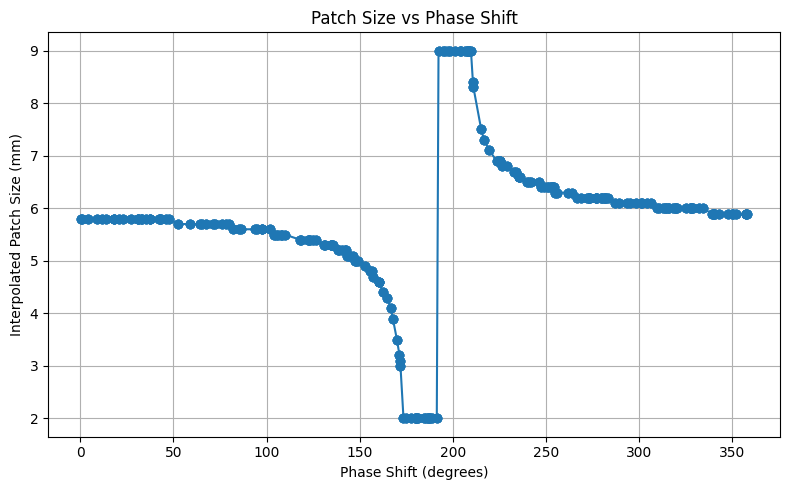

In [ ]:
df = pd.read_csv("reflectarray_phase_shift_interpolated_nearest.csv")  # <- Change this to your file path

# 2. Define the column names (make sure they match the exact headers in your CSV)
phase_col = 'Phase Shift (degrees)'
patch_col = 'Interpolated Patch Size (mm)'

# 3. (Optional) Sort data by phase for better visualization
df = df.sort_values(by=phase_col)

# 4. Plot the graph
plt.figure(figsize=(8, 5))  # Set the figure size (width x height)
plt.plot(df[phase_col], df[patch_col], marker='o', linestyle='-')  # Line plot with markers

# 5. Add labels and title
plt.title('Patch Size vs Phase Shift')  # Plot title
plt.xlabel('Phase Shift (degrees)')     # X-axis label
plt.ylabel('Interpolated Patch Size (mm)')  # Y-axis label

# 6. Add grid lines for clarity
plt.grid(True)

# 7. Adjust layout and show the plot
plt.tight_layout()
plt.show()

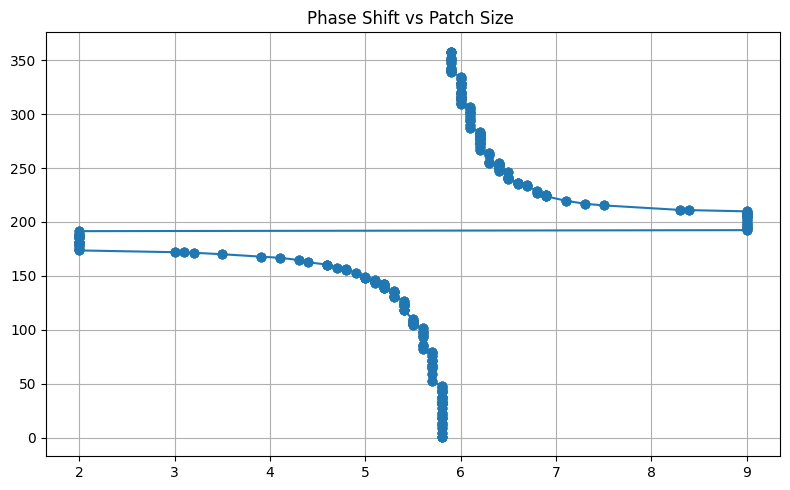

In [ ]:
# 3. (Optional) Sort data by phase for better visualization
df = df.sort_values(by=phase_col)

# 4. Plot the graph
plt.figure(figsize=(8, 5))  # Set the figure size (width x height)
plt.plot(df[patch_col], df[phase_col], marker='o', linestyle='-')  # Line plot with markers
plt.title('Phase Shift vs Patch Size ')  # Plot title


# 6. Add grid lines for clarity
plt.grid(True)

# 7. Adjust layout and show the plot
plt.tight_layout()
plt.show()

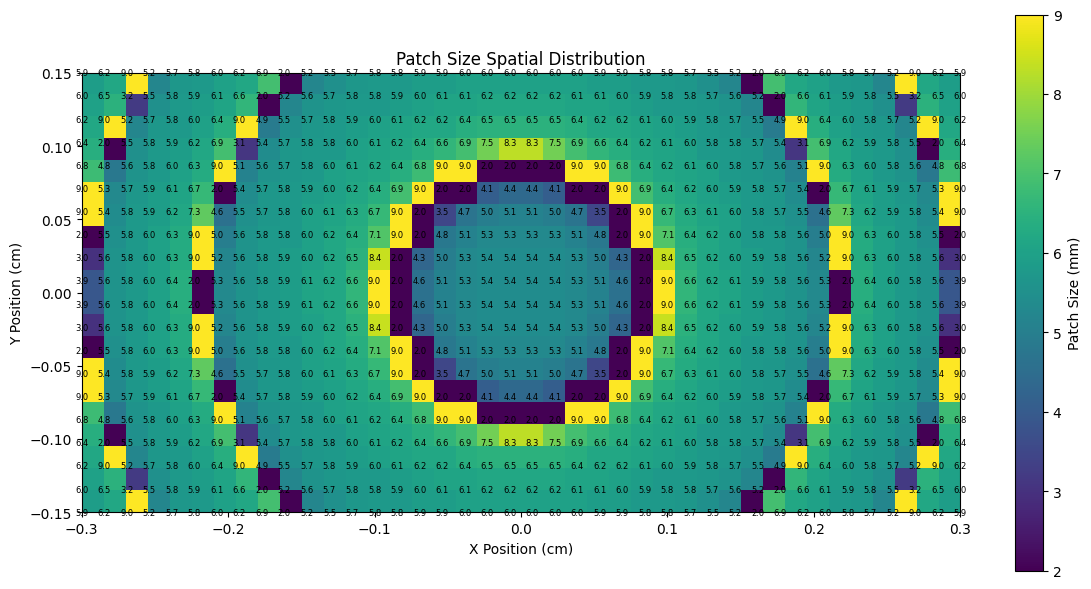

In [ ]:


df = pd.read_csv('reflectarray_phase_shift_interpolated_nearest.csv')

patch_matrix = df.pivot(index='Y (m)', columns='X (m)', values='Interpolated Patch Size (mm)')

# 3. Plot the 2D patch size heatmap
fig, ax = plt.subplots(figsize=(12, 6))

# Display the patch size as a color map
im = ax.imshow(patch_matrix.values, cmap='viridis', origin='lower',
               extent=[patch_matrix.columns.min(), patch_matrix.columns.max(),
                       patch_matrix.index.min(), patch_matrix.index.max()])

# 4. Add colorbar and labels
plt.colorbar(im, ax=ax, label='Patch Size (mm)')
ax.set_title('Patch Size Spatial Distribution')
ax.set_xlabel('X Position (cm)')
ax.set_ylabel('Y Position (cm)')

# 5. Overlay squared patch sizes (area in mm²) as text labels
ny, nx = patch_matrix.shape
x_labels = patch_matrix.columns.to_numpy()
y_labels = patch_matrix.index.to_numpy()

for i in range(ny):
    for j in range(nx):
        patch_size = patch_matrix.values[i, j]
        patch_area = patch_size   # Square the size to get area
        ax.text(x_labels[j], y_labels[i], f'{patch_area:.1f}', ha='center', va='center', color='black', fontsize=6)

plt.tight_layout()
plt.savefig("PATCH.png", dpi=300, bbox_inches='tight')
plt.show()
